# Siamese Network com MNIST

**Paulo Lisboa de Almeida**

Rede siamesa que aprende embeddings para comparar imagens de dígitos manuscritos. São utilizados somente os dígitos **1, 2, 3, 4 e 5**.

Ao final da aula, faça os seguintes testes:

1 - Teste com todos os dígitos.

2 - Teste com embeddings de tamanhos diferentes.


In [2]:
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

PROJECT_DIR = Path.cwd().resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / "siamese_mnist_best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)


Dispositivo: cuda


In [13]:
DIGITS = [1, 2, 3, 4, 5,6,7,8,9] #Vamos filtrar para conter apenas dígitos de 1 a 9

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#Pesquise na internet, ou calcule você mesmo. 0.1307 e 0.3081 são a média e o desvio padrão do dataset
#A normalização é feita por Z-Score

mnist_train = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

def filtro(dataset, digits):
    mask = torch.zeros(len(dataset.targets), dtype=torch.bool)
    for digit in digits:
        mask |= (dataset.targets == digit)
    return torch.where(mask)[0].tolist()

indices = filtro(mnist_train, DIGITS)
test_indices = filtro(mnist_test, DIGITS)

rng = np.random.default_rng()
rng.shuffle(indices)
split = int(0.8 * len(indices))

train_base = Subset(mnist_train, indices[:split])
val_base = Subset(mnist_train, indices[split:])
test_base = Subset(mnist_test, test_indices)

print(f'Treino:    {len(train_base):,} imagens')
print(f'Validação: {len(val_base):,} imagens')
print(f'Teste:     {len(test_base):,} imagens')


Treino:    43,261 imagens
Validação: 10,816 imagens
Teste:     9,020 imagens


In [14]:
class TripletDataset(Dataset):
    def __init__(self, base_dataset, digits, triplets_per_epoch=10000):
        self.dataset = base_dataset
        self.digits = list(digits)
        self.triplets_per_epoch = triplets_per_epoch
        self.rng = random.Random()

        self.class_indices = {digit: [] for digit in self.digits}
        for i in range(len(self.dataset)):
            _, label = self.dataset[i]
            self.class_indices[int(label)].append(i)

        self.gerar_triplets()

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        anchor, _ = self.dataset[a]
        positive, _ = self.dataset[p]
        negative, _ = self.dataset[n]
        return anchor, positive, negative

    def gerar_triplets(self):
        self.triplets = []

        for _ in range(self.triplets_per_epoch):
            positive_class = self.rng.choice(self.digits)
            negative_class = self.rng.choice(
                [d for d in self.digits if d != positive_class]
            )

            a, p = self.rng.sample(self.class_indices[positive_class], 2)
            n = self.rng.choice(self.class_indices[negative_class])

            self.triplets.append((a, p, n))

train_triplets = TripletDataset(train_base, DIGITS, 12000)
val_triplets = TripletDataset(val_base, DIGITS, 2500)

print('Triplets de treino:', len(train_triplets))
print('Triplets de validação:', len(val_triplets))


Triplets de treino: 12000
Triplets de validação: 2500


Exemplos de triplets


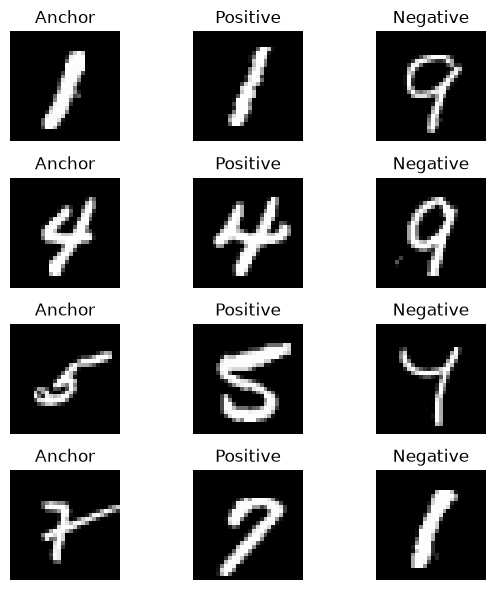

In [15]:
print("Exemplos de triplets")
NUM_EXAMPLES = 4

fig, axes = plt.subplots(NUM_EXAMPLES, 3, figsize=(6, 6))

for row in range(NUM_EXAMPLES):
    anchor, positive, negative = train_triplets[random.randint(0,len(train_triplets))]

    for col, (image, title) in enumerate([
        (anchor, 'Anchor'), (positive, 'Positive'), (negative, 'Negative')
    ]):
        image = image.squeeze().numpy() * 0.3081 + 0.1307
        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title(title)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [16]:
class EmbeddingNetwork(nn.Module):
    def __init__(self, embedding_dim=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), #convolução 3x3, com 32 canais de saída
            nn.ReLU(),
            nn.MaxPool2d(2), #feature map 14x14

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), #feature map 7x7

            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, embedding_dim)
        )

    def forward(self, x):
        return self.embedding(self.features(x))


class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=2):
        super().__init__()
        self.embedding_network = EmbeddingNetwork(embedding_dim)

    def forward(self, input1, input2=None):
        embedding1 = self.embedding_network(input1)

        if input2 is None:
            return embedding1

        embedding2 = self.embedding_network(input2)
        return torch.norm(embedding1 - embedding2, p=2, dim=1)


In [17]:
test_loader = DataLoader(
    test_base, batch_size=256, shuffle=False, num_workers=0
)

def mostrarEmbeddings(loader):
  embeddings = []
  labels = []

  with torch.no_grad():
      for images, batch_labels in tqdm(loader, desc='Calculando embeddings'):
          images = images.to(device)
          batch_embeddings = model(images).cpu().numpy()

          embeddings.append(batch_embeddings)
          labels.append(batch_labels.numpy())

  embeddings = np.concatenate(embeddings)
  labels = np.concatenate(labels)

  plt.figure(figsize=(10, 8))

  for digit in DIGITS:
      mask = labels == digit
      plt.scatter(
          embeddings[mask, 0],
          embeddings[mask, 1],
          s=8,
          alpha=0.35,
          label=f'Dígito {digit}'
      )

  plt.xlabel("Dim 1")
  plt.ylabel("Dim 2")
  plt.title("Embeddings")
  plt.legend()
  plt.grid(True)
  plt.show()


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 45.73it/s]


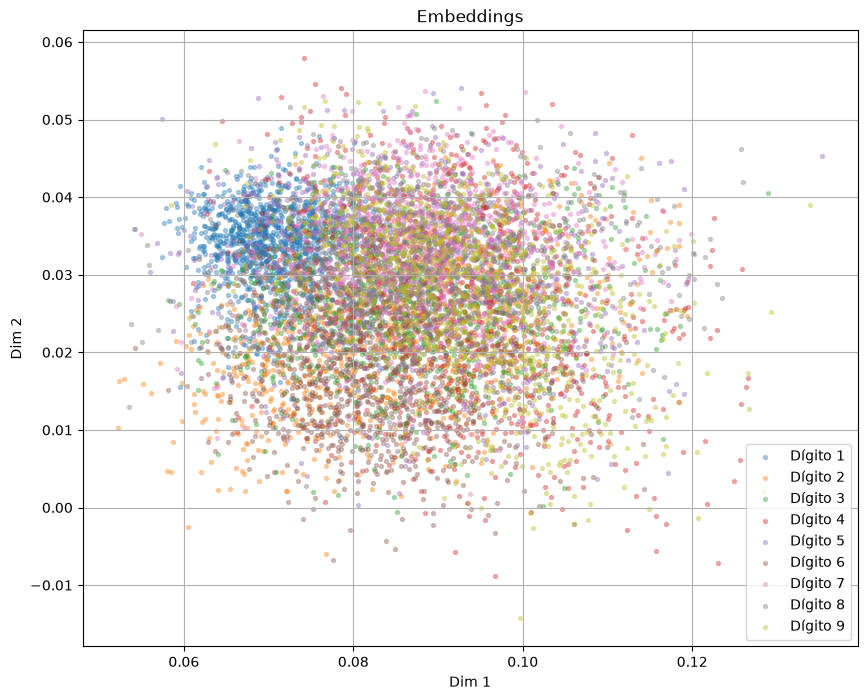

Epoch 01: train loss = 0.2571 | val loss = 0.1187


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 62.26it/s]


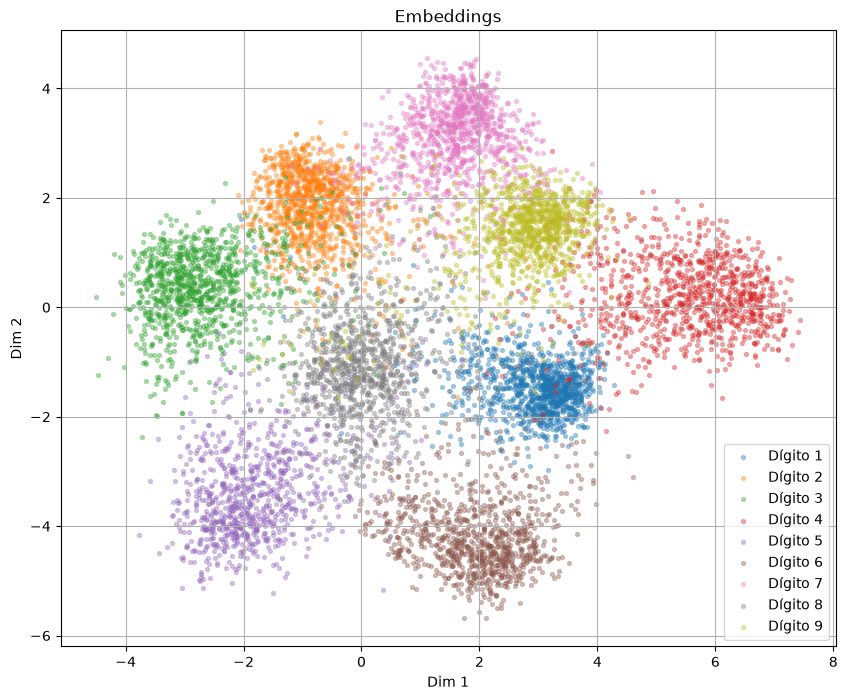

Epoch 02: train loss = 0.0911 | val loss = 0.0815


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 61.71it/s]


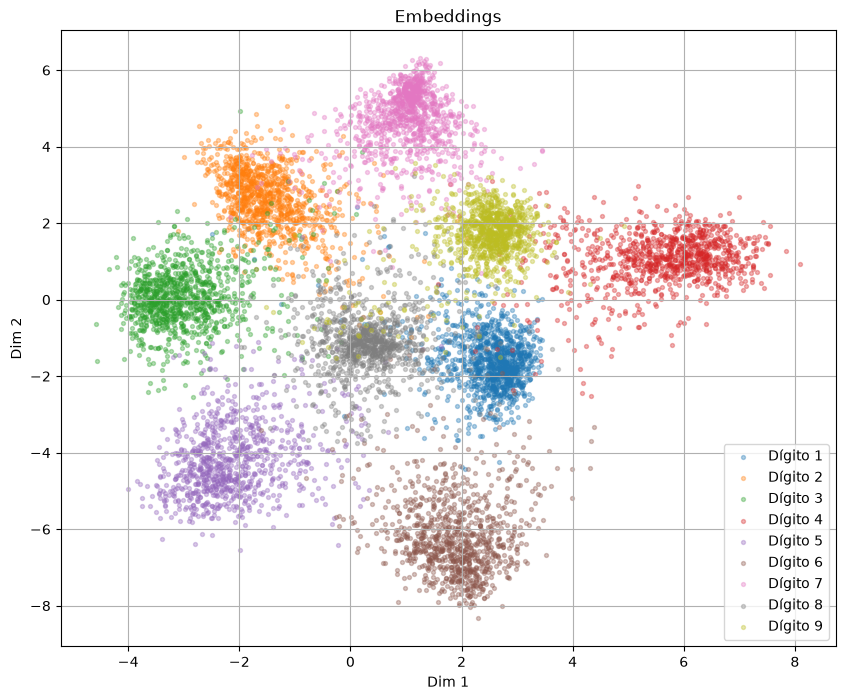

Epoch 03: train loss = 0.0744 | val loss = 0.0760


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 62.18it/s]


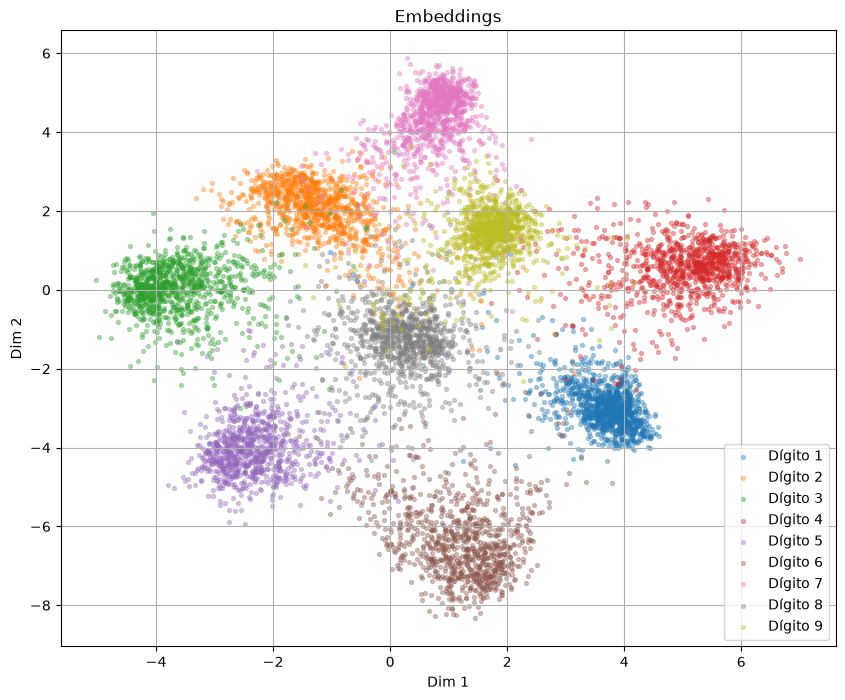

Epoch 04: train loss = 0.0577 | val loss = 0.0537


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 61.60it/s]


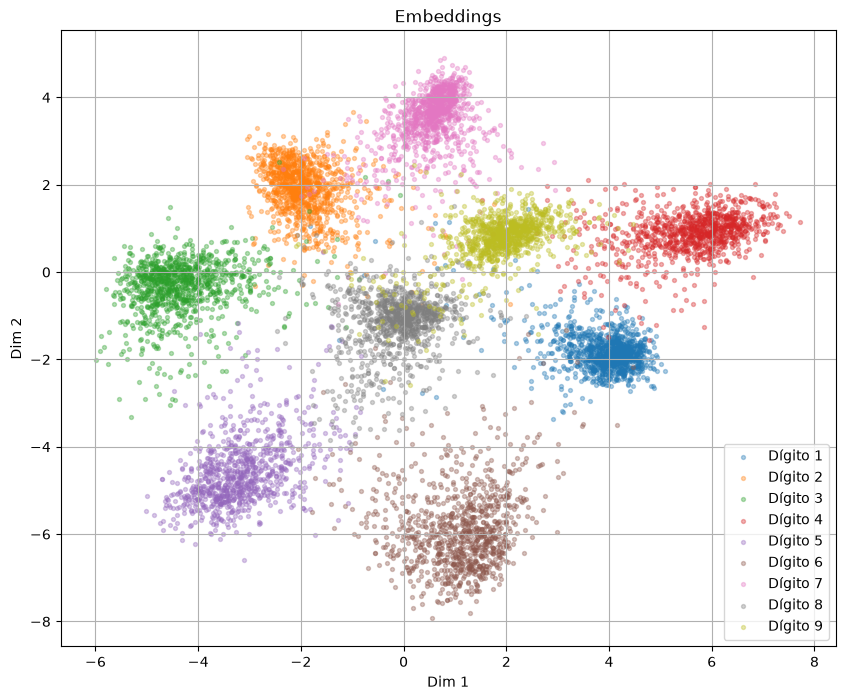

Epoch 05: train loss = 0.0563 | val loss = 0.0523


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 62.17it/s]


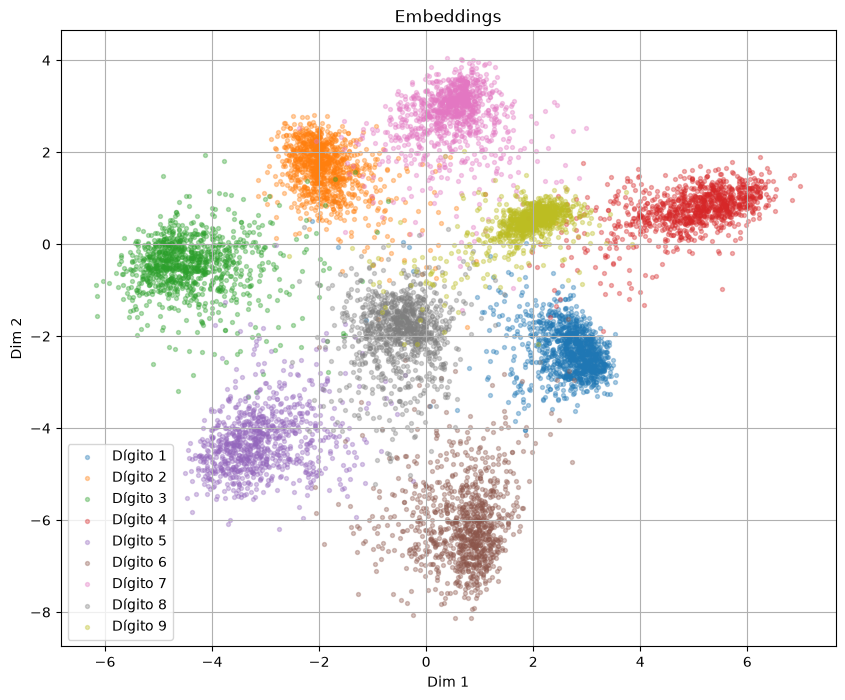

Epoch 06: train loss = 0.0491 | val loss = 0.0540


Calculando embeddings: 100%|██████████| 36/36 [00:00<00:00, 62.92it/s]


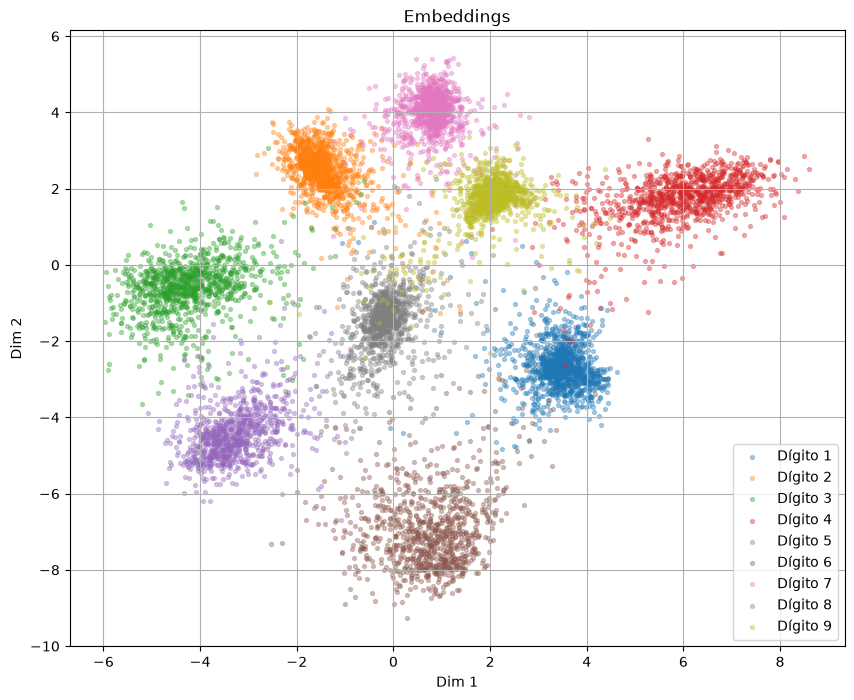

In [18]:
BATCH_SIZE = 64
EPOCHS = 6
LEARNING_RATE = 1e-3
MARGIN = 1.0

model = SiameseNetwork(embedding_dim=2).to(device)

train_loader = DataLoader(
    train_triplets, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_triplets, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available()
)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

#O swap faz o achor swap descrito no paper do Balntas
#BALNTAS, Vassileios et al. Learning local feature descriptors with triplets and shallow convolutional neural networks. In: Bmvc. 2016. p. 3.
#Depois habilitem e vejam se converge mais rápido. Provavelmente não, já que esse problema é bobo. Mas a técnica é legal
criterion = nn.TripletMarginLoss(margin=MARGIN, p=2.0, swap=False)

best_val_loss = float("inf")
history = {"train": [], "val": []}

for epoch in range(EPOCHS):
    mostrarEmbeddings(test_loader)
    train_triplets.gerar_triplets()
    model.train()
    train_loss = 0.0

    for anchor, positive, negative in tqdm(
        train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=False
    ):
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()

        anchor_out = model(anchor)
        positive_out = model(positive)
        negative_out = model(negative)

        loss = criterion(anchor_out, positive_out, negative_out)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for anchor, positive, negative in val_loader:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            loss = criterion(
                model(anchor), model(positive), model(negative)
            )
            val_loss += loss.item()

    val_loss /= len(val_loader)
    history["train"].append(train_loss)
    history["val"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

    print(
        f"Epoch {epoch + 1:02d}: "
        f"train loss = {train_loss:.4f} | val loss = {val_loss:.4f}"
    )

mostrarEmbeddings(test_loader)


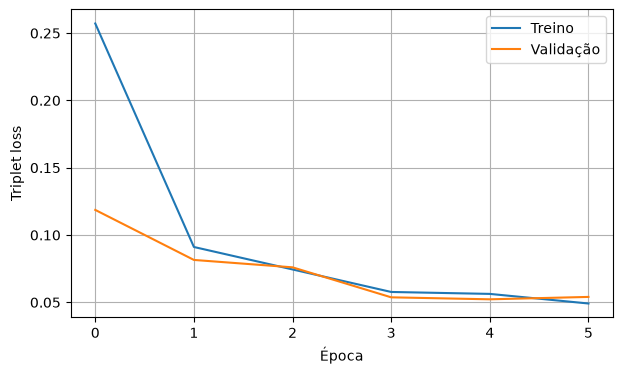

SiameseNetwork(
  (embedding_network): EmbeddingNetwork(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (7): ReLU()
    )
    (embedding): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=3136, out_features=128, bias=True)
      (2): ReLU()
      (3): Linear(in_features=128, out_features=2, bias=True)
    )
  )
)

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history["train"], label="Treino")
plt.plot(history["val"], label="Validação")
plt.xlabel("Época")
plt.ylabel("Triplet loss")
plt.legend()
plt.grid(True)
plt.show()

model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
)
model.eval()


In [20]:
class PairDataset(Dataset):
    def __init__(self, base_dataset, digits, pairs_per_class=500):
        self.dataset = base_dataset
        self.rng = random.Random()
        self.class_indices = {digit: [] for digit in digits}

        for i in range(len(self.dataset)):
            _, label = self.dataset[i]
            self.class_indices[int(label)].append(i)

        self.pairs = []

        # Pares do mesmo dígito
        for digit in digits:
            for _ in range(pairs_per_class):
                a, b = self.rng.sample(self.class_indices[digit], 2)
                self.pairs.append((a, b, 0))

        # Pares de dígitos diferentes
        for _ in range(len(self.pairs)):
            d1, d2 = self.rng.sample(list(digits), 2)
            a = self.rng.choice(self.class_indices[d1])
            b = self.rng.choice(self.class_indices[d2])
            self.pairs.append((a, b, 1))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        a, b, label = self.pairs[idx]
        image_a, _ = self.dataset[a]
        image_b, _ = self.dataset[b]
        return image_a, image_b, label


def get_distances(model, pair_dataset, batch_size=256):
    loader = DataLoader(
        pair_dataset, batch_size=batch_size, shuffle=False, num_workers=0
    )

    distances = []
    labels = []

    with torch.no_grad():
        for image_a, image_b, label in loader:
            image_a = image_a.to(device)
            image_b = image_b.to(device)

            distances.extend(
                model(image_a, image_b).cpu().numpy()
            )
            labels.extend(label.numpy())

    return np.asarray(distances), np.asarray(labels)


val_pairs = PairDataset(val_base, DIGITS, pairs_per_class=500)
val_distances, val_labels = get_distances(model, val_pairs)

# Gambiarra. Entre a menor distância possível, e maior, geramos 500 valores
# Testamos os 500 para encontrar o valor que maximiza a acurácia
# Ideias melhores para você implementar depois em casa:
# 1 - Calcular via Equal Error Rate na curva AUC
# 2 - Usar o método do paper https://arxiv.org/pdf/2607.05329
thresholds = np.linspace(val_distances.min(), val_distances.max(), 500)

accuracies = [
    np.mean((val_distances >= t).astype(int) == val_labels)
    for t in thresholds
]

best_idx = int(np.argmax(accuracies))
threshold = thresholds[best_idx]

print(f'Threshold escolhido na validação: {threshold:.4f}')
print(f'Acurácia de validação: {accuracies[best_idx]:.4f}')


Threshold escolhido na validação: 2.4058
Acurácia de validação: 0.9466


In [21]:
# Avaliação final no conjunto de teste oficial do MNIST.
test_pairs = PairDataset(test_base, DIGITS, pairs_per_class=1000)
test_distances, test_labels = get_distances(model, test_pairs)

test_predictions = (test_distances >= threshold).astype(int)
test_accuracy = np.mean(test_predictions == test_labels)

print(f'Número de pares de teste: {len(test_labels):,}')
print(f'Acurácia no teste: {test_accuracy:.4f}')


Número de pares de teste: 18,000
Acurácia no teste: 0.9464


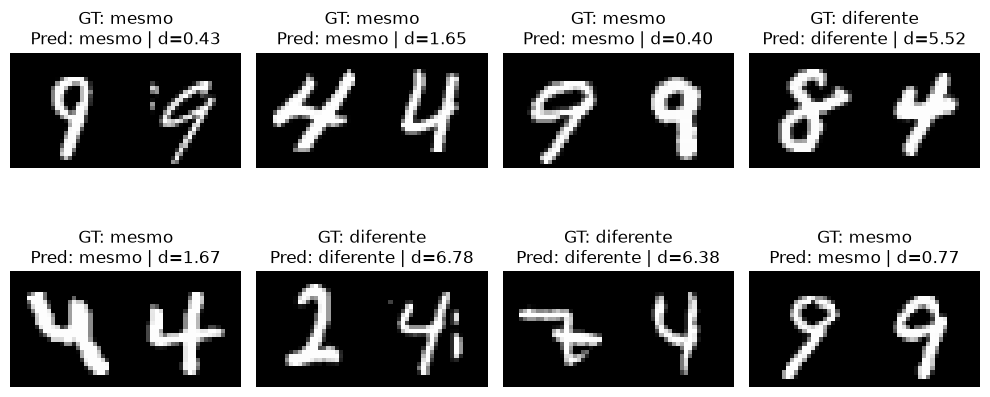

In [22]:
def show_test_examples(pair_dataset, distances, labels, predictions, n=8):
    indices = np.random.choice(
        len(pair_dataset), size=min(n, len(pair_dataset)), replace=False
    )

    fig, axes = plt.subplots(2, 4, figsize=(10, 5))
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        image_a, image_b, label = pair_dataset[idx]

        image_a = image_a.squeeze().numpy() * 0.3081 + 0.1307
        image_b = image_b.squeeze().numpy() * 0.3081 + 0.1307
        combined = np.concatenate([image_a, image_b], axis=1)

        ax.imshow(combined, cmap='gray')

        real = 'mesmo' if label == 0 else 'diferente'
        pred = 'mesmo' if predictions[idx] == 0 else 'diferente'

        ax.set_title(
            f'GT: {real}\nPred: {pred} | d={distances[idx]:.2f}'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_test_examples(
    test_pairs, test_distances, test_labels, test_predictions
)


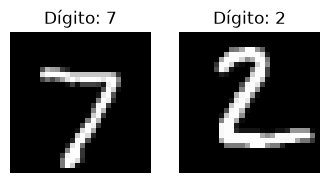

Distância entre embeddings: 3.1178
Resultado: dígitos diferentes


In [25]:
# Experimento final: compare duas imagens escolhidas pelo índice.

def compare_images(dataset, idx1, idx2):
    image1, label1 = dataset[idx1]
    image2, label2 = dataset[idx2]

    with torch.no_grad():
        distance = model(
            image1.unsqueeze(0).to(device),
            image2.unsqueeze(0).to(device)
        ).item()

    prediction = (
        'mesmo dígito' if distance < threshold
        else 'dígitos diferentes'
    )

    fig, axes = plt.subplots(1, 2, figsize=(4, 2))

    for ax, image, label in zip(
        axes, [image1, image2], [label1, label2]
    ):
        image = image.squeeze().numpy() * 0.3081 + 0.1307
        ax.imshow(image, cmap='gray')
        ax.set_title(f'Dígito: {label}')
        ax.axis('off')

    plt.show()

    print(f'Distância entre embeddings: {distance:.4f}')
    print(f'Resultado: {prediction}')


# Altere os índices para experimentar com outras imagens.
compare_images(test_base, 0, 1)
